In [2]:
!pip install easyocr opencv-python-headless

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 362, in run
    resolver = self.make_resolver(
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 177, in make_resolver
    return pip._internal.resolution.resolvelib.resolver.Resolver(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 58, in __init__
    self.factory = Factory(
                   ^^^^^^^^
  File "/usr/local/lib/py

In [3]:
import cv2
import easyocr
import matplotlib.pyplot as plt
import numpy as np

In [5]:
from google.colab import files
uploaded = files.upload()

Saving IMG_9369.jpeg to IMG_9369.jpeg


In [7]:
image_path = "IMG_9369.jpeg"

In [14]:
img = cv2.imread(image_path)

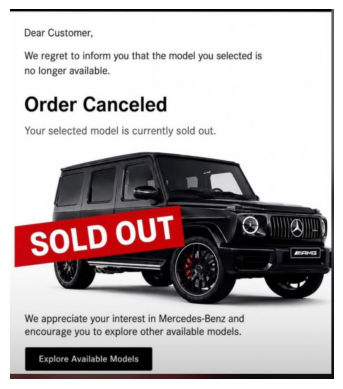

In [16]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()



In [17]:
reader = easyocr.Reader(['en'], gpu=False)

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [18]:
text_ = reader.readtext(img)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [19]:
print (text_)

[([[np.int32(30), np.int32(41)], [np.int32(196), np.int32(41)], [np.int32(196), np.int32(70)], [np.int32(30), np.int32(70)]], 'Dear Customer,', np.float64(0.6152076836503014)), ([[np.int32(31), np.int32(91)], [np.int32(591), np.int32(91)], [np.int32(591), np.int32(127)], [np.int32(31), np.int32(127)]], 'We regret to inform you that the model you selected is', np.float64(0.7265413995397293)), ([[np.int32(31), np.int32(135)], [np.int32(61), np.int32(135)], [np.int32(61), np.int32(155)], [np.int32(31), np.int32(155)]], 'no', np.float64(0.9996582061694328)), ([[np.int32(60), np.int32(129)], [np.int32(236), np.int32(129)], [np.int32(236), np.int32(162)], [np.int32(60), np.int32(162)]], 'longer available:', np.float64(0.6756198043261833)), ([[np.int32(26), np.int32(194)], [np.int32(372), np.int32(194)], [np.int32(372), np.int32(248)], [np.int32(26), np.int32(248)]], 'Order Canceled', np.float64(0.9999855035981379)), ([[np.int32(32), np.int32(268)], [np.int32(478), np.int32(268)], [np.int32(4

In [32]:
 threshold = 0.25

In [34]:
for t_, t in enumerate(text_):
    print(t)

    bbox, text, score = t

    if score > threshold:
        cv2.rectangle(img,
                      tuple(map(int, bbox[0])),
                      tuple(map(int, bbox[2])),
                      (0, 255, 0),
                      5)
        cv2.putText(img,
                    text,
                    tuple(map(int, bbox[0])),
                    cv2.FONT_HERSHEY_COMPLEX,
                    0.65,
                    (255, 0, 0),
                    2)


([[np.int32(30), np.int32(41)], [np.int32(196), np.int32(41)], [np.int32(196), np.int32(70)], [np.int32(30), np.int32(70)]], 'Dear Customer,', np.float64(0.6152076836503014))
([[np.int32(31), np.int32(91)], [np.int32(591), np.int32(91)], [np.int32(591), np.int32(127)], [np.int32(31), np.int32(127)]], 'We regret to inform you that the model you selected is', np.float64(0.7265413995397293))
([[np.int32(31), np.int32(135)], [np.int32(61), np.int32(135)], [np.int32(61), np.int32(155)], [np.int32(31), np.int32(155)]], 'no', np.float64(0.9996582061694328))
([[np.int32(60), np.int32(129)], [np.int32(236), np.int32(129)], [np.int32(236), np.int32(162)], [np.int32(60), np.int32(162)]], 'longer available:', np.float64(0.6756198043261833))
([[np.int32(26), np.int32(194)], [np.int32(372), np.int32(194)], [np.int32(372), np.int32(248)], [np.int32(26), np.int32(248)]], 'Order Canceled', np.float64(0.9999855035981379))
([[np.int32(32), np.int32(268)], [np.int32(478), np.int32(268)], [np.int32(478), n

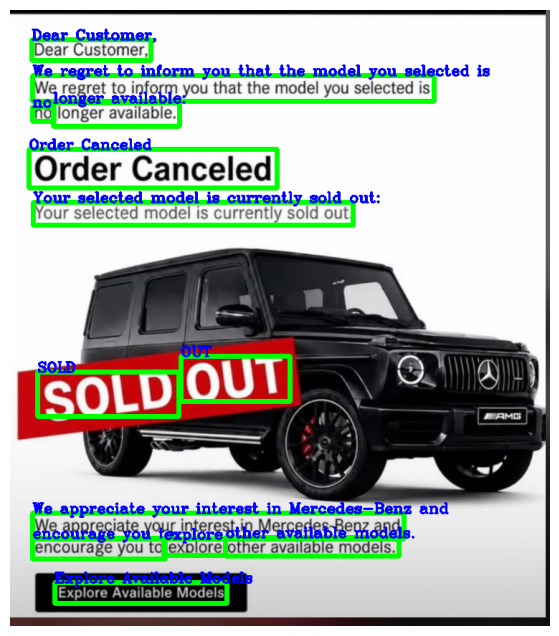

In [37]:
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()